# Thesis Plots — Part 1: Core Results & Model Failure Analysis

**Plot 1a** — Overall QUR by Dataset × Configuration  
**Plot 1b** — QUR by Corruption Complexity (C1/C2/C3)  
**Plot 2a** — QUR by NLP Entity Type (radar)  
**Plot 2b** — QUR by Document Element Type (horizontal bar)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ── Paths ────────────────────────────────────────────────────────────────────
RESULTS_DIR = "/home/amartinelli/VRD-UQA/results_final"   # relative to this notebook
OUTPUT_DIR  = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Experiment axes ──────────────────────────────────────────────────────────
DATASETS = ["DUDE", "MPDocVQA", "SlideVQA", "BDocs"]
CONFIGS  = ["zeroshot", "fewshot", "finetuned"]

DATASET_LABELS = {"DUDE": "DUDE", "MPDocVQA": "MPDocVQA",
                  "SlideVQA": "SlideVQA", "BDocs": "BoundingDocs"}
CONFIG_LABELS  = {"zeroshot": "Zero-Shot", "fewshot": "Few-Shot",
                  "finetuned": "Fine-Tuned (LoRA)"}

# ── Visual style ─────────────────────────────────────────────────────────────
COLORS = {"zeroshot": "#4C72B0", "fewshot": "#DD8452", "finetuned": "#55A868"}

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.size":       10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "axes.axisbelow":  True,
    "grid.linestyle":  "--",
    "grid.alpha":      0.5,
})

def load_csv(dataset, config, filename):
    """Load a results CSV; returns a Series indexed by row label, or None."""
    path = os.path.join(RESULTS_DIR, dataset, config, filename)
    if not os.path.exists(path):
        print(f"[MISSING] {path}")
        return None
    df = pd.read_csv(path, index_col=0)
    df.columns = ["value"]
    return df["value"]

## Load QUR data

In [2]:
records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR.csv")
        if s is None:
            continue
        # QUR_C3 = 0.0 means no C3 questions exist in this split → treat as NaN
        c3_val = s.get("QUR_C3", np.nan)
        if c3_val == 0.0:
            c3_val = np.nan
        records.append({
            "dataset": dataset,
            "config":  config,
            "QUR":     s.get("QUR",    np.nan),
            "QUR_C1":  s.get("QUR_C1", np.nan),
            "QUR_C2":  s.get("QUR_C2", np.nan),
            "QUR_C3":  c3_val,
        })

qur_df = pd.DataFrame(records)
qur_df

,dataset,config,QUR,QUR_C1,QUR_C2,QUR_C3
0,DUDE,zeroshot,0.630000,0.651376,0.621622,0.125000
1,DUDE,fewshot,0.620000,0.619266,0.648649,0.375000
2,DUDE,finetuned,0.996667,0.995413,1.000000,1.000000
3,MPDocVQA,zeroshot,0.566667,0.527027,0.671642,0.727273
4,MPDocVQA,fewshot,0.513333,0.468468,0.626866,0.727273
5,MPDocVQA,finetuned,0.986667,0.981982,1.000000,1.000000
6,SlideVQA,zeroshot,0.580000,0.502591,0.681159,0.789474
7,SlideVQA,fewshot,0.473333,0.409326,0.565217,0.631579
8,SlideVQA,finetuned,0.970000,0.963731,0.971014,1.000000
9,BDocs,zeroshot,0.710000,0.663900,0.898305,NaN


## Plot 1a — Overall QUR by Dataset × Configuration

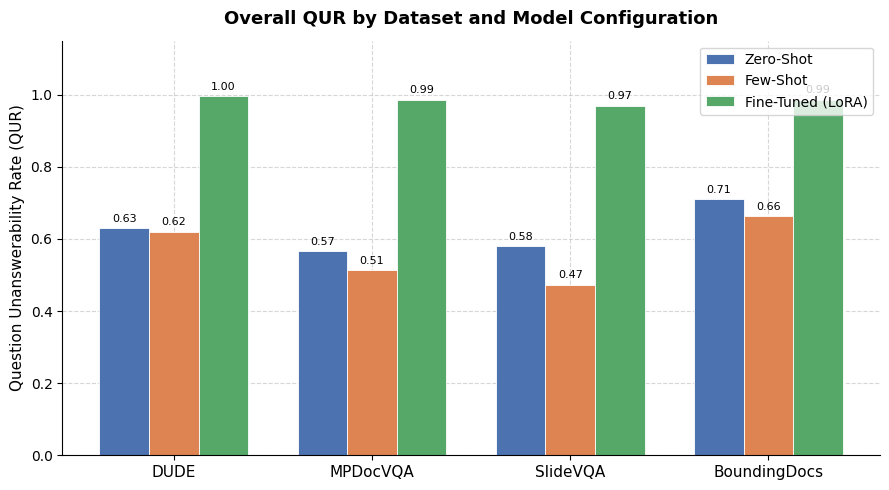

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

bar_width = 0.25
x = np.arange(len(DATASETS))

for i, config in enumerate(CONFIGS):
    vals = [qur_df.loc[(qur_df.dataset == d) & (qur_df.config == config), "QUR"].values[0]
            for d in DATASETS]
    bars = ax.bar(x + i * bar_width, vals, width=bar_width,
                  color=COLORS[config], label=CONFIG_LABELS[config],
                  edgecolor="white", linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + bar_width)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS], fontsize=11)
ax.set_ylabel("Question Unanswerability Rate (QUR)", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Overall QUR by Dataset and Model Configuration",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plot1a_qur_overall.pdf"), bbox_inches="tight")
plt.show()

## Plot 1b — QUR by Corruption Complexity Level (C1 / C2 / C3)

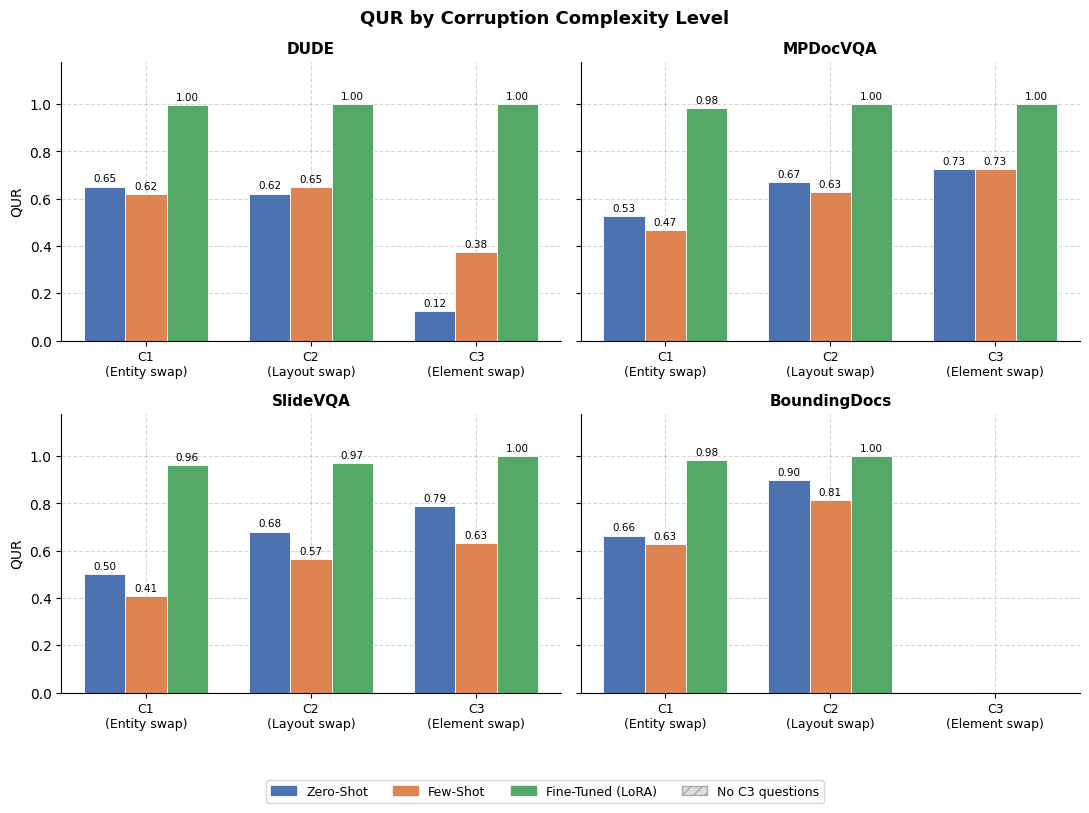

In [4]:
COMPLEXITY_COLS   = ["QUR_C1", "QUR_C2", "QUR_C3"]
COMPLEXITY_LABELS = ["C1\n(Entity swap)", "C2\n(Layout swap)", "C3\n(Element swap)"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
axes = axes.flatten()

bar_width = 0.25
x = np.arange(len(COMPLEXITY_COLS))

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    for i, config in enumerate(CONFIGS):
        row = qur_df[(qur_df.dataset == dataset) & (qur_df.config == config)]
        if row.empty:
            continue
        vals = [row[c].values[0] for c in COMPLEXITY_COLS]
        # Skip NaN bars gracefully
        plot_vals = [v if not np.isnan(v) else 0 for v in vals]
        bars = ax.bar(x + i * bar_width, plot_vals, width=bar_width,
                      color=COLORS[config], label=CONFIG_LABELS[config],
                      edgecolor="white", linewidth=0.6)
        # Hatch NaN bars to signal missing data
        for bar, val in zip(bars, vals):
            if np.isnan(val):
                bar.set_hatch("///")
                bar.set_edgecolor("#aaaaaa")
                bar.set_facecolor("#dddddd")
            else:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(COMPLEXITY_LABELS, fontsize=9)
    ax.set_ylim(0, 1.18)
    if idx % 2 == 0:
        ax.set_ylabel("QUR", fontsize=10)

handles = [mpatches.Patch(color=COLORS[c], label=CONFIG_LABELS[c]) for c in CONFIGS]
na_patch = mpatches.Patch(facecolor="#dddddd", edgecolor="#aaaaaa",
                           hatch="///", label="No C3 questions")
fig.legend(handles=handles + [na_patch], loc="lower center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("QUR by Corruption Complexity Level",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot1b_qur_complexity.pdf"), bbox_inches="tight")
plt.show()

## Load NLP Entity (NLPE) data

In [5]:
ENTITY_TYPES = ["NUMERIC", "TEMPORAL", "ENTITY", "LOCATION", "STRUCTURE"]

nlpe_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR_NLPE.csv")
        if s is None:
            continue
        for etype in ENTITY_TYPES:
            nlpe_records.append({
                "dataset":     dataset,
                "config":      config,
                "entity_type": etype,
                "QUR":         s.get(etype, np.nan),
            })

nlpe_df = pd.DataFrame(nlpe_records)
nlpe_df.pivot_table(index=["dataset", "config"], columns="entity_type", values="QUR")

entity_type           ENTITY  LOCATION   NUMERIC  STRUCTURE  TEMPORAL
dataset  config                                                      
BDocs    fewshot    0.546667  0.666667  0.858974   0.606383  0.826087
         finetuned  0.960000  1.000000  1.000000   0.989362  1.000000
         zeroshot   0.693333  0.712121  0.871795   0.638298  0.847826
DUDE     fewshot    0.649746  0.620690  0.428571   0.560000  1.000000
         finetuned  0.994924  1.000000  1.000000   1.000000  1.000000
         zeroshot   0.725888  0.465517  0.714286   0.472000  1.000000
MPDocVQA fewshot    0.581818  0.354839  0.647059   0.495495  0.583333
         finetuned  0.993939  0.967742  0.970588   0.990991  1.000000
         zeroshot   0.624242  0.451613  0.764706   0.495495  0.687500
SlideVQA fewshot    0.583333  0.325926  0.700000   0.300000  0.600000
         finetuned  0.983333  0.962963  0.962500   1.000000  1.000000
         zeroshot   0.672222  0.466667  0.837500   0.650000  0.566667

## Plot 2a — QUR by NLP Entity Type (Radar / Spider Chart)

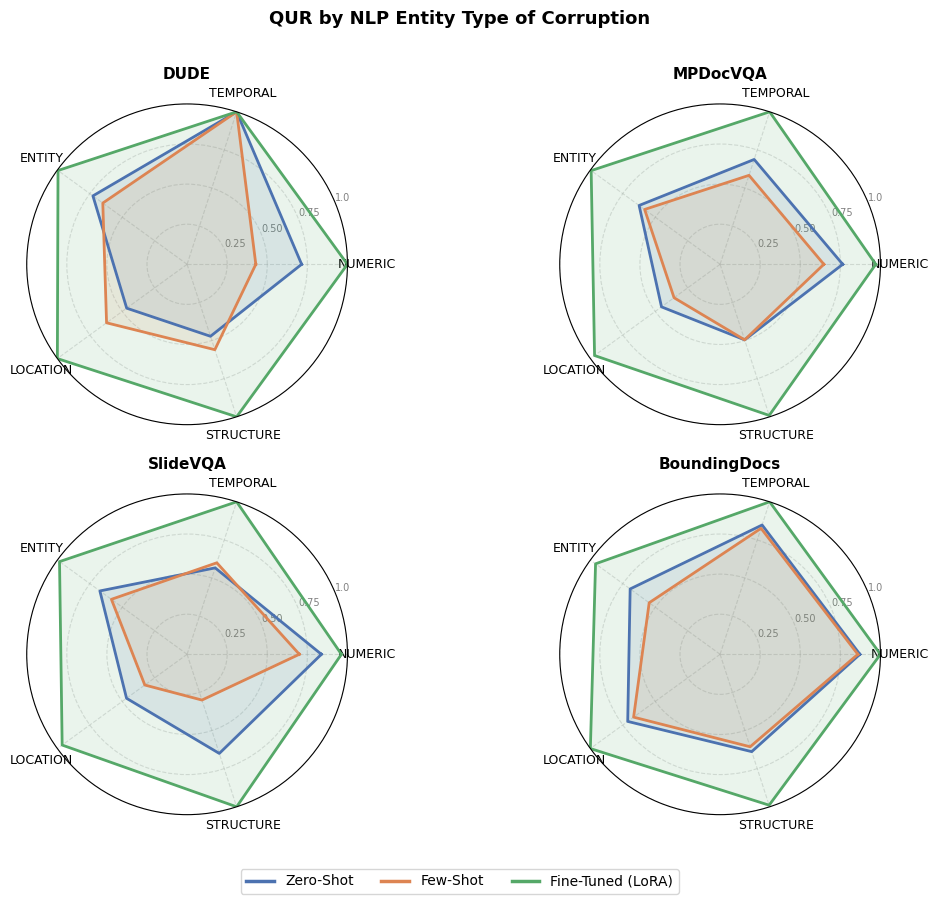

In [6]:
N      = len(ENTITY_TYPES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, axes = plt.subplots(2, 2, figsize=(11, 9),
                         subplot_kw={"projection": "polar"})
axes = axes.flatten()

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]

    for config in CONFIGS:
        sub = nlpe_df[(nlpe_df.dataset == dataset) & (nlpe_df.config == config)]
        if sub.empty:
            continue
        vals = [sub.loc[sub.entity_type == et, "QUR"].values[0]
                if et in sub.entity_type.values else 0
                for et in ENTITY_TYPES]
        vals += vals[:1]
        ax.plot(angles, vals,
                color=COLORS[config], linewidth=2,
                label=CONFIG_LABELS[config])
        ax.fill(angles, vals, color=COLORS[config], alpha=0.12)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(ENTITY_TYPES, fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.0"], fontsize=7, color="grey")
    ax.set_title(DATASET_LABELS[dataset], fontsize=11,
                 fontweight="bold", pad=18)
    ax.grid(True, linestyle="--", alpha=0.4)

handles = [Line2D([0], [0], color=COLORS[c], linewidth=2.5,
                  label=CONFIG_LABELS[c]) for c in CONFIGS]
fig.legend(handles=handles, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("QUR by NLP Entity Type of Corruption",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, "plot2a_qur_nlpe_radar.pdf"), bbox_inches="tight")
plt.show()

## Load Document Element (DE) data

In [7]:
# Canonical element name → display label
DE_RENAME = {
    "title":            "Title",
    "plain text":       "Plain Text",
    "figure":           "Figure",
    "figure_caption":   "Fig. Caption",
    "table":            "Table",
    "table_caption":    "Table Caption",
    "table_footnote":   "Table Footnote",
    "abandon":          "Abandon",
    "isolate_formula":  "Formula",
    "formula_caption":  "Formula Caption",
}

de_records = []
for dataset in DATASETS:
    for config in CONFIGS:
        s = load_csv(dataset, config, "QUR_DE.csv")
        if s is None:
            continue
        for elem, val in s.items():
            if val > 0:   # 0.0 means the element type is absent in this dataset
                de_records.append({
                    "dataset": dataset,
                    "config":  config,
                    "element": DE_RENAME.get(elem, elem),
                    "QUR":     val,
                })

de_df = pd.DataFrame(de_records)

# Keep only elements that appear in at least 2 datasets (avoids singleton noise)
counts = de_df.groupby("element")["dataset"].nunique()
common_elements = counts[counts >= 2].index.tolist()
de_df = de_df[de_df.element.isin(common_elements)]

print("Element types retained:", sorted(de_df.element.unique()))

Element types retained: ['Abandon', 'Figure', 'Plain Text', 'Table', 'Table Footnote', 'Title']


## Plot 2b — QUR by Document Element Type (Horizontal Bar)

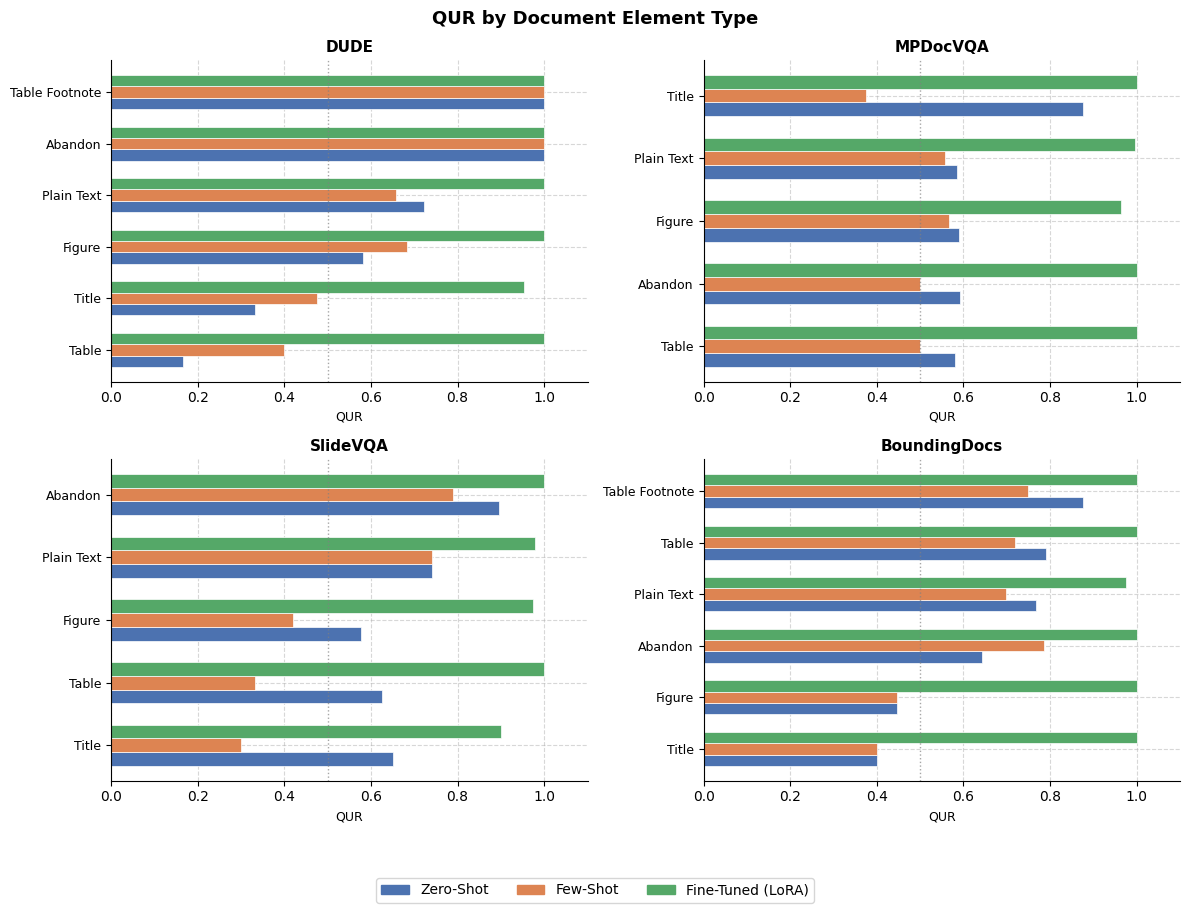

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for idx, dataset in enumerate(DATASETS):
    ax = axes[idx]
    sub = de_df[de_df.dataset == dataset]
    if sub.empty:
        ax.set_visible(False)
        continue

    # Sort elements by average QUR (ascending → hardest at bottom)
    elem_order = (sub.groupby("element")["QUR"]
                    .mean()
                    .sort_values(ascending=True)
                    .index.tolist())

    n_elems  = len(elem_order)
    n_cfgs   = len(CONFIGS)
    bar_h    = 0.22
    y_base   = np.arange(n_elems)

    for i, config in enumerate(CONFIGS):
        csub = sub[sub.config == config].set_index("element")
        vals = [csub.loc[e, "QUR"] if e in csub.index else np.nan
                for e in elem_order]
        ax.barh(y_base + i * bar_h, vals, height=bar_h,
                color=COLORS[config], label=CONFIG_LABELS[config],
                edgecolor="white", linewidth=0.5)

    ax.set_yticks(y_base + bar_h)
    ax.set_yticklabels(elem_order, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel("QUR", fontsize=9)
    ax.set_title(DATASET_LABELS[dataset], fontsize=11, fontweight="bold")
    ax.axvline(0.5, color="grey", linestyle=":", linewidth=1, alpha=0.7)

handles = [mpatches.Patch(color=COLORS[c], label=CONFIG_LABELS[c]) for c in CONFIGS]
fig.legend(handles=handles, loc="lower center",
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("QUR by Document Element Type",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(OUTPUT_DIR, "plot2b_qur_de_horizontal.pdf"), bbox_inches="tight")
plt.show()